In [1]:
import kagglehub

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.optim as optim 
import matplotlib.pyplot as plt

In [3]:
print(torch.__version__)

2.9.0+cu126


In [4]:
path = kagglehub.dataset_download("zalando-research/fashionmnist")
print("Path to dataset files ", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files  /kaggle/input/fashionmnist


In [6]:
%pip install opendataset
import pandas as pd

In [7]:
import opendatasets as od
od.download(
    "https://www.kaggle.com/datasets/zalando-research/fashionmnist"
)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist


100%|██████████| 68.8M/68.8M [00:00<00:00, 1.23GB/s]

api key = KGAT_855e10921136a5797597d02a8d21b456


In [8]:
!ls /content
!ls /content/fashionmnist


fashionmnist  sample_data
fashion-mnist_test.csv	 t10k-images-idx3-ubyte  train-images-idx3-ubyte
fashion-mnist_train.csv  t10k-labels-idx1-ubyte  train-labels-idx1-ubyte


In [9]:
train_df = pd.read_csv('/content/fashionmnist/fashion-mnist_train.csv')
test_df  = pd.read_csv("/content/fashionmnist/fashion-mnist_test.csv")

print(train_df.shape)
train_df.head()


(60000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
small_train_df = train_df[:6000]
small_train_df.shape

(6000, 785)

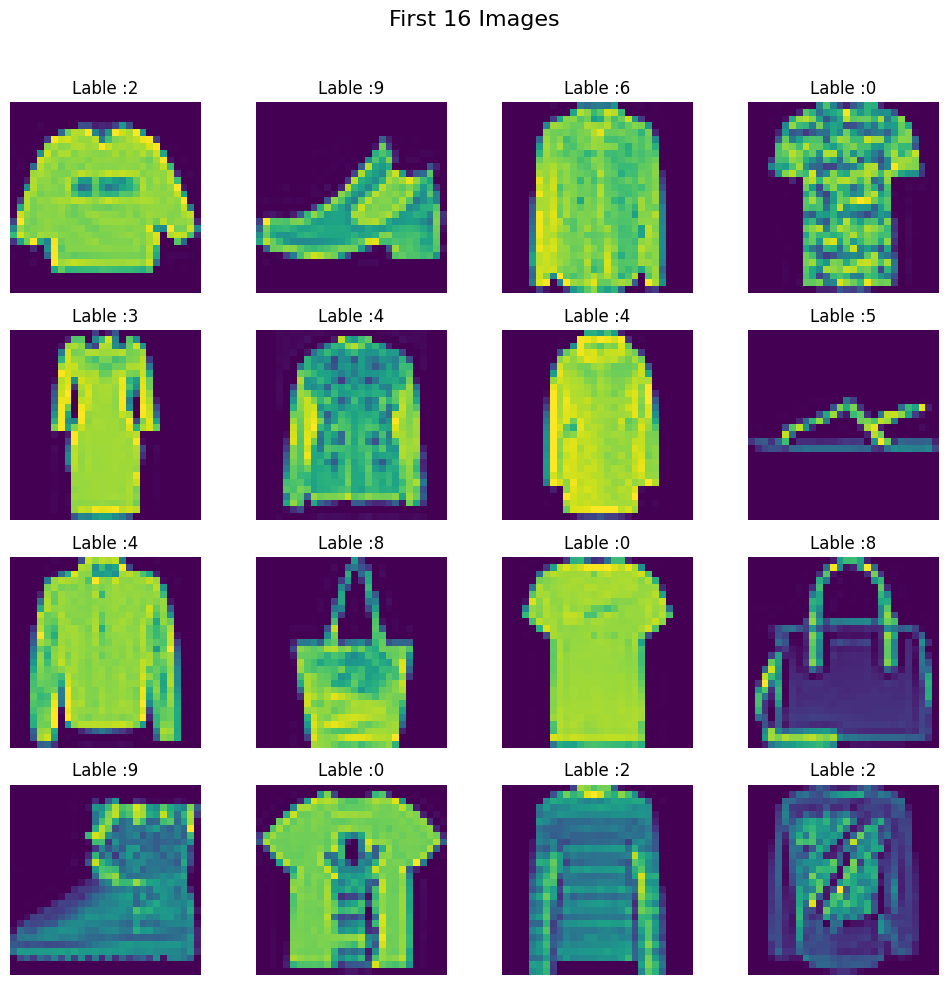

In [13]:
fig, ax = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)


for i, a in enumerate(ax.flat):
    img = small_train_df.iloc[i,1:].values.reshape(28,28)
    a.imshow(img)
    a.axis('off')
    a.set_title(f"Lable :{small_train_df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()    

In [14]:
X = small_train_df.iloc[:,1:].values
y = small_train_df.iloc[:,0].values

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


NameError: name 'X' is not defined

In [16]:
# scaling the feature 

X_train = X_train/255.0
X_test = X_test/255.0

## Custom Dataset Class

In [17]:
class customDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):

        return self.features[index], self.labels[index]


In [18]:
train_dataset = customDataset(X_train, y_train)

In [19]:
len(train_dataset)

4800

In [20]:
test_dataset = customDataset(X_test,y_test)

In [21]:
len(test_dataset)

1200

In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Define NN Class

In [23]:
epochs = 101
learning_rate = 0.1

class myNN(nn.Module):

    def __init__(self, num_feature):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_feature,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10),
        )
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.SGD(self.parameters(), lr=learning_rate)

    def forward(self, feature):
        return self.network(feature)

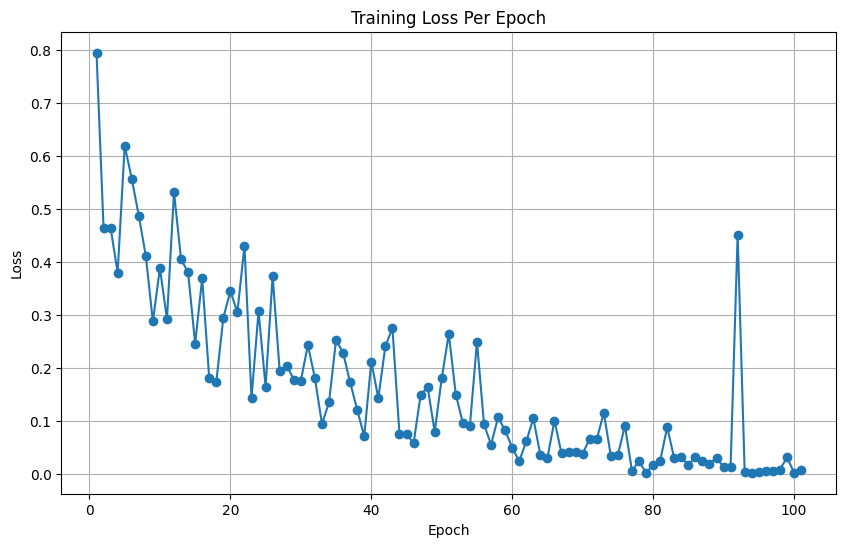

In [24]:
model = myNN(X_train.shape[1])
losses = []

# training loop 

for epoch in range(epochs):
    for batch_features, batch_labels in train_loader:
        # forward 
        outputs = model(batch_features)

        # loss 
        loss = model.criterion(outputs,batch_labels)

        # backward 
        model.optimizer.zero_grad()
        loss.backward()

        # Gradients update 
        model.optimizer.step()

    losses.append(loss.item())


fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1,epochs+1),losses,marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Per Epoch")
ax.grid(True)
plt.show()



In [25]:
model.eval()

myNN(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
  (criterion): CrossEntropyLoss()
)

In [26]:
# evaluation code 

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0] 
        correct += (predicted == batch_labels).sum().item()

print(correct/total)        



0.86


## Training On GPU 

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [11]:
X = train_df.iloc[:,1:].values
y = train_df.iloc[:,0].values

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
# scaling the feature 

X_train = X_train/255.0
X_test = X_test/255.0

## Custom dataset class 


In [14]:
class customDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):

        return self.features[index], self.labels[index]


In [29]:
train_dataset = customDataset(X_train, y_train)
test_dataset = customDataset(X_test,y_test)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,pin_memory=True)

Define NN Class 

In [16]:
epochs = 101
learning_rate = 0.1

class myNN(nn.Module):

    def __init__(self, num_feature):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_feature,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10),
        )
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.SGD(self.parameters(), lr=learning_rate)

    def forward(self, feature):
        return self.network(feature)

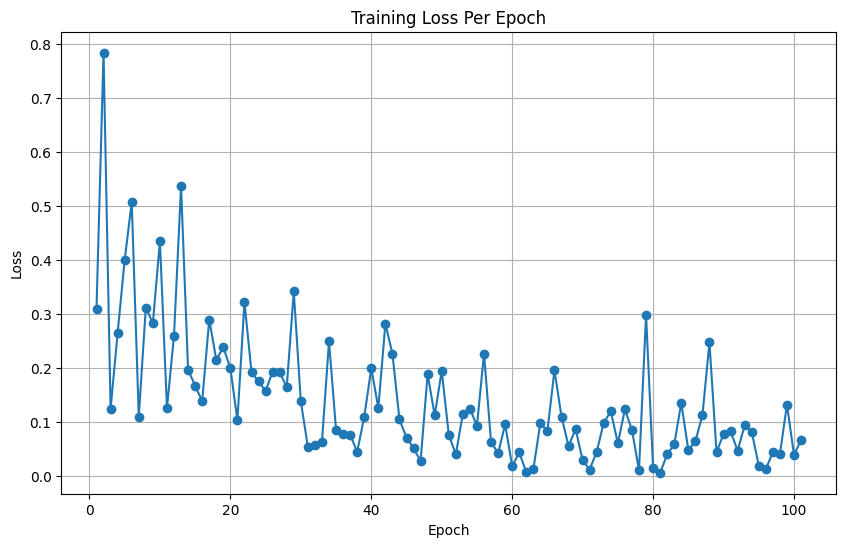

In [40]:
model = myNN(X_train.shape[1])
model = model.to(device)
losses = []

# training loop 

for epoch in range(epochs):
    for batch_features, batch_labels in train_loader:

        # move data to gpu 
        batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)
        # forward 
        outputs = model(batch_features)

        # loss 
        loss = model.criterion(outputs,batch_labels)

        # backward 
        model.optimizer.zero_grad()
        loss.backward()

        # Gradients update 
        model.optimizer.step()

    losses.append(loss.item())


fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1,epochs+1),losses,marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Per Epoch")
ax.grid(True)
plt.show()



In [41]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # move data to gpu 
        batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)

        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0] 
        correct += (predicted == batch_labels).sum().item()

print(correct/total)   

0.8888333333333334


In [42]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        # move data to gpu 
        batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)

        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0] 
        correct += (predicted == batch_labels).sum().item()

print(correct/total)   

0.9804166666666667


## Optimizing the NN

In [17]:
epochs = 101
learning_rate = 0.1

class myNN(nn.Module):

    def __init__(self, num_feature):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_feature,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64,10),
        )
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.SGD(self.parameters(), lr=learning_rate,weight_decay=1e-4)

    def forward(self, feature):
        return self.network(feature)

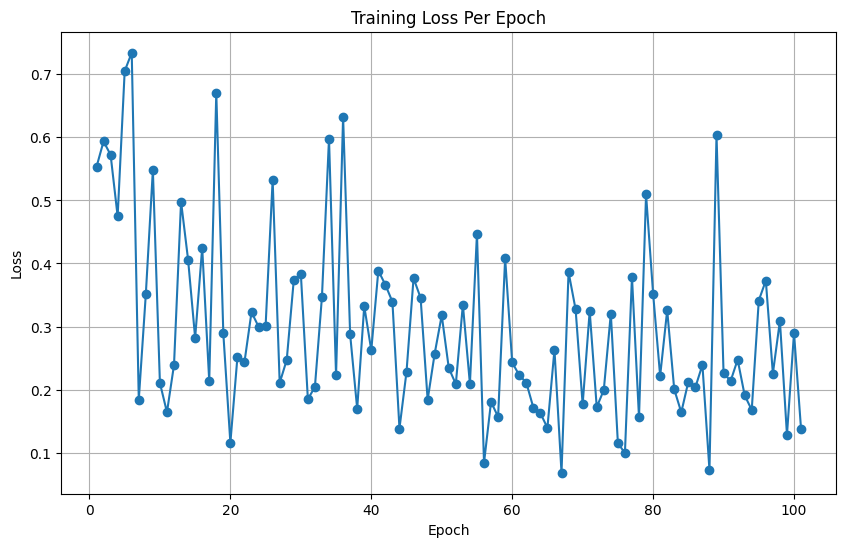

In [44]:
model = myNN(X_train.shape[1])
model = model.to(device)
losses = []

# training loop 

for epoch in range(epochs):
    for batch_features, batch_labels in train_loader:

        # move data to gpu 
        batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)
        # forward 
        outputs = model(batch_features)

        # loss 
        loss = model.criterion(outputs,batch_labels)

        # backward 
        model.optimizer.zero_grad()
        loss.backward()

        # Gradients update 
        model.optimizer.step()

    losses.append(loss.item())


fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1,epochs+1),losses,marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Per Epoch")
ax.grid(True)
plt.show()



In [47]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # move data to gpu 
        batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)

        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0] 
        correct += (predicted == batch_labels).sum().item()

print(correct/total)   

0.8938333333333334


In [48]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in train_loader:
        # move data to gpu 
        batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)

        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0] 
        correct += (predicted == batch_labels).sum().item()

print(correct/total)   

0.9433333333333334


## Hyperparameter Tuning


In [30]:

class myHPTNN(nn.Module):

    def __init__(self,input_dim, output_dim, num_hidden_layer,neuron_per_layer,dropout_rate):

        super().__init__()

        layers = []

        for i in range(num_hidden_layer):
            layers.append(nn.Linear(input_dim, neuron_per_layer))
            layers.append(nn.BatchNorm1d(neuron_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

            input_dim = neuron_per_layer
        layers.append(nn.Linear(neuron_per_layer, output_dim))

        self.model = nn.Sequential(*layers)  

    def forward(self, x):
        return self.model(x)       

In [34]:
# objective function 
def objective(trial):
    # next hyperparameter values from the search space 
    num_hidden_layer = trial.suggest_int("num_hidden_layer",1,5)

    neuron_per_layer = trial.suggest_int("neuron_per_layer",8,128, step=8)
    epochs = trial.suggest_int("epochs",10,50,step=10)
    learning_rate = trial.suggest_float("learning_rate",1e-5,1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate",0.1,0.5,step=0.1)
    batch_size = trial.suggest_categorical("batch_size",[16,32,64,128])
    optimizer_name = trial.suggest_categorical("optimizer_name",['Adam','SGD','RMSprop'])
    
    weight_decay = trial.suggest_float("weight_decay", 1e-5,1e-3, log=True)


    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,pin_memory=True)

    # model init
    input_dim = 784
    output_dim = 10

    model = myHPTNN(input_dim, output_dim,num_hidden_layer,neuron_per_layer,dropout_rate)
    model.to(device)

    # pramas init 
    criterion = nn.CrossEntropyLoss()

    # #  optimizer selection 
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    if optimizer_name == 'Adam':
        optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'SGD':
        optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else :
        optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)    

    # training loop 

    losses = [] 
    for epoch in range(epochs):
        for batch_features, batch_labels in train_loader:

            # move data to gpu 
            batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)
            # forward 
            outputs = model(batch_features)

            # loss 
            loss = criterion(outputs,batch_labels)

            # backward 
            optimizer.zero_grad()
            
            loss.backward()

            # Gradients update 
            optimizer.step()

        losses.append(loss.item())


    fig, ax = plt.subplots(figsize=(10,6))
    ax.plot(range(1,epochs+1),losses,marker='o')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training Loss Per Epoch")
    ax.grid(True)
    plt.show()

    # evaluation 

    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            # move data to gpu 
            batch_features, batch_labels = batch_features.to(device),batch_labels.to(device)

            outputs = model(batch_features)

            _,predicted = torch.max(outputs,1)

            total += batch_labels.shape[0] 
            correct += (predicted == batch_labels).sum().item()

    accuracy = (correct/total)   

    return accuracy


In [21]:
%pip install optuna

In [35]:
import optuna 

study = optuna.create_study(direction='maximize')


[I 2026-02-05 15:14:24,547] A new study created in memory with name: no-name-e2ecead4-4ea2-46fc-acc1-db2d6f0ff893


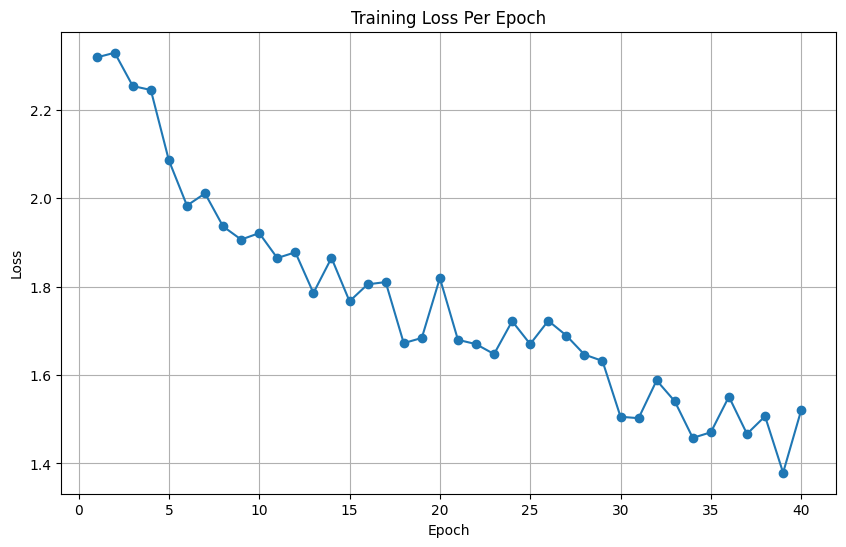

[I 2026-02-05 15:15:46,051] Trial 0 finished with value: 0.69625 and parameters: {'num_hidden_layer': 2, 'neuron_per_layer': 80, 'epochs': 40, 'learning_rate': 1.4786728281163004e-05, 'dropout_rate': 0.2, 'batch_size': 64, 'optimizer_name': 'Adam', 'weight_decay': 3.7670941022894105e-05}. Best is trial 0 with value: 0.69625.


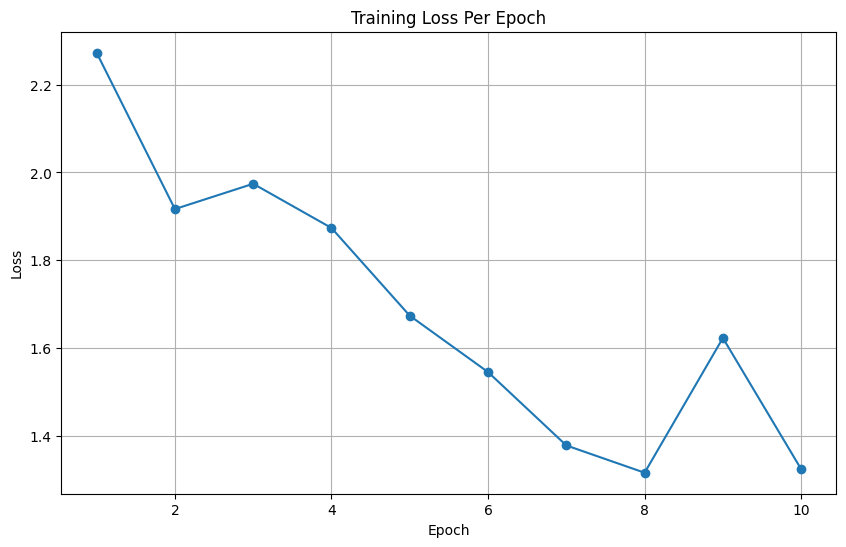

[I 2026-02-05 15:16:53,008] Trial 1 finished with value: 0.7069166666666666 and parameters: {'num_hidden_layer': 2, 'neuron_per_layer': 64, 'epochs': 10, 'learning_rate': 3.193066158555065e-05, 'dropout_rate': 0.30000000000000004, 'batch_size': 16, 'optimizer_name': 'RMSprop', 'weight_decay': 0.0005293768480859411}. Best is trial 1 with value: 0.7069166666666666.


In [ ]:
study.optimize(objective, n_trials=10)

In [ ]:
study.best_value

In [ ]:
study.best_params